In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   
import holidays
import os

import ipywidgets as widgets
from ipywidgets import interact, fixed
import calendar
import random 

import warnings
warnings.filterwarnings('ignore')

In [65]:
#This part is imported the fucntions from the utils.py file. 
import sys
sys.path.append("../")

from src.utils.utils import fill_missing_values, correct_outliers,add_template 
from src.utils.plots import plot_daily_qty_for_month  

In [66]:
data= pd.read_csv('../data/data.csv')
print(data.head())

  shipped_date     sku channel  qty   revenue  cost of good sold  MOQ order
0     1/1/2021  089A0E     ADS  190   5027.40            2926.00      56460
1     1/1/2021  089A0E     AWH   30    793.80                NaN      56460
2     1/1/2021  0FKFLA     AWH  780  32028.36           13104.00     427545
3     1/1/2021  0G8Z4M     AWH   85   1307.81             595.00       2516
4     1/1/2021  0NFJ14     FBM   38   2127.47            1723.25      18734


1. Overview the data

In [67]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 48363 entries, 0 to 48362
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   shipped_date       48363 non-null  str    
 1   sku                48363 non-null  str    
 2   channel            48363 non-null  str    
 3   qty                48363 non-null  int64  
 4   revenue            44099 non-null  float64
 5   cost of good sold  43311 non-null  float64
 6   MOQ order          48363 non-null  int64  
dtypes: float64(2), int64(2), str(3)
memory usage: 2.6 MB


In [68]:
data.rename(columns={'cost of good sold': 'COGS','MOQ order':'MOQ_orders'}, inplace=True)

In [69]:
#lọc các giá trị ko hợp lệ trước khi fillna bằng giá trị mean theo sku
data = data.loc[
    ((data['qty'] > 0) | data['qty'].isna()) &
    ((data['revenue'] > 0) | data['revenue'].isna()) &
    ((data['COGS'] > 0) | data['COGS'].isna())
].copy()

In [70]:
data_filled = fill_missing_values(data)

In [71]:
print(data_filled.shape)
print(data_filled.isna().sum())

(48157, 7)
shipped_date     0
sku              0
channel          0
qty              0
revenue         28
COGS            22
MOQ_orders       0
dtype: int64


In [72]:
#revenue still missing because it only have 1 day sales in the data --> so we remove it for now
data_filled = data_filled.dropna(subset=['revenue'])

In [73]:
#lọc giá trị có revenue/qty =0, COGS>0
data_processed = data_filled.loc[
    ~(
        ((data_filled['revenue'] == 0) | (data_filled['qty'] == 0)) &
        (data_filled['COGS'] > 0)
    )]

In [74]:
data_processed.shape

(48129, 7)

3. Start EDA

3.1. Check correlation

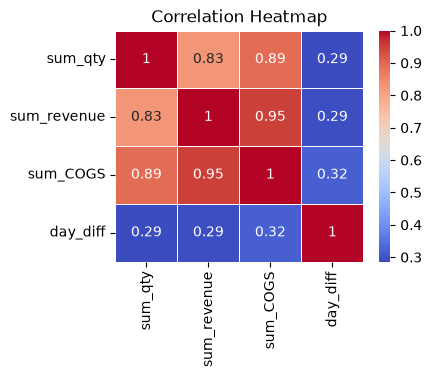

In [75]:
data_processed['shipped_date'] = pd.to_datetime(data_processed['shipped_date'])
data_group = data_processed.groupby('sku').agg({'shipped_date': ['min', 'max'],
                                      'qty': 'sum',
                                      'revenue':'sum',
                                      'COGS':'sum'})


data_group.columns = ['min_date', 'max_date', 'sum_qty', 'sum_revenue', 'sum_COGS']
data_group['day_diff'] = (data_group['max_date'] - data_group['min_date']).dt.days
data_group = data_group.reset_index()
data_corr = data_group.corr(numeric_only=True)
plt.figure(figsize=(4,3))
sns.heatmap(data_corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [76]:
data_group['day_diff'] = (data_group['max_date'] - data_group['min_date']).dt.days
data_group['day_diff'].describe()

count    663.000000
mean     218.705882
std      144.819742
min        0.000000
25%       69.000000
50%      256.000000
75%      364.000000
max      366.000000
Name: day_diff, dtype: float64

3.2 Choose top 20% SKUs that contribute most to revenue to forecast: (by the Pareto principle)

In [77]:
## Filter top 20% SKU by revenue, which likely contribute to the majority of sales:
data_group_sorted = data_group.sort_values(by='sum_revenue', ascending=False)
top_n = int(len(data_group_sorted) * 0.2)
top_20_percent_sku = data_group_sorted.head(top_n)['sku'].tolist()
print(len(top_20_percent_sku))

132


In [78]:
data_group_sku = data.groupby(['shipped_date', 'sku']).agg({'qty': 'sum', 'revenue':'sum', 'COGS':'sum'}).reset_index()
data_forecast = data_group_sku[data_group_sku['sku'].isin(top_20_percent_sku)]
print(data_forecast.shape)
data_forecast.head()

(20893, 5)


,shipped_date,sku,qty,revenue,COGS
1,1/1/2021,0FKFLA,780,32028.36,13104.00
4,1/1/2021,11HSH1,150,7137.90,6209.97
5,1/1/2021,13KMDL,444,31048.92,8018.64
6,1/1/2021,17KYMH,966,54144.30,25411.60
9,1/1/2021,1JKADT,3038,46742.67,33627.72


3.4 Fill the data that not have fully in dataset:

In [79]:
data_forecast['shipped_date'] = pd.to_datetime(data_forecast['shipped_date'])
data_forecast_template = add_template(data_forecast, min_date = data_forecast['shipped_date'].min(), max_date = data_forecast['shipped_date'].max(), skus = data_forecast['sku'].unique())
data_forecast_template['month'] = data_forecast_template['shipped_date'].dt.month
print(data_forecast_template.shape)
data_forecast_template.head(3)

(6996, 6)


,shipped_date,sku,qty,revenue,COGS,month
0,2021-01-01,0FKFLA,780.0,32028.36,13104.00,1
1,2021-01-01,11HSH1,150.0,7137.90,6209.97,1
2,2021-01-01,13KMDL,444.0,31048.92,8018.64,1


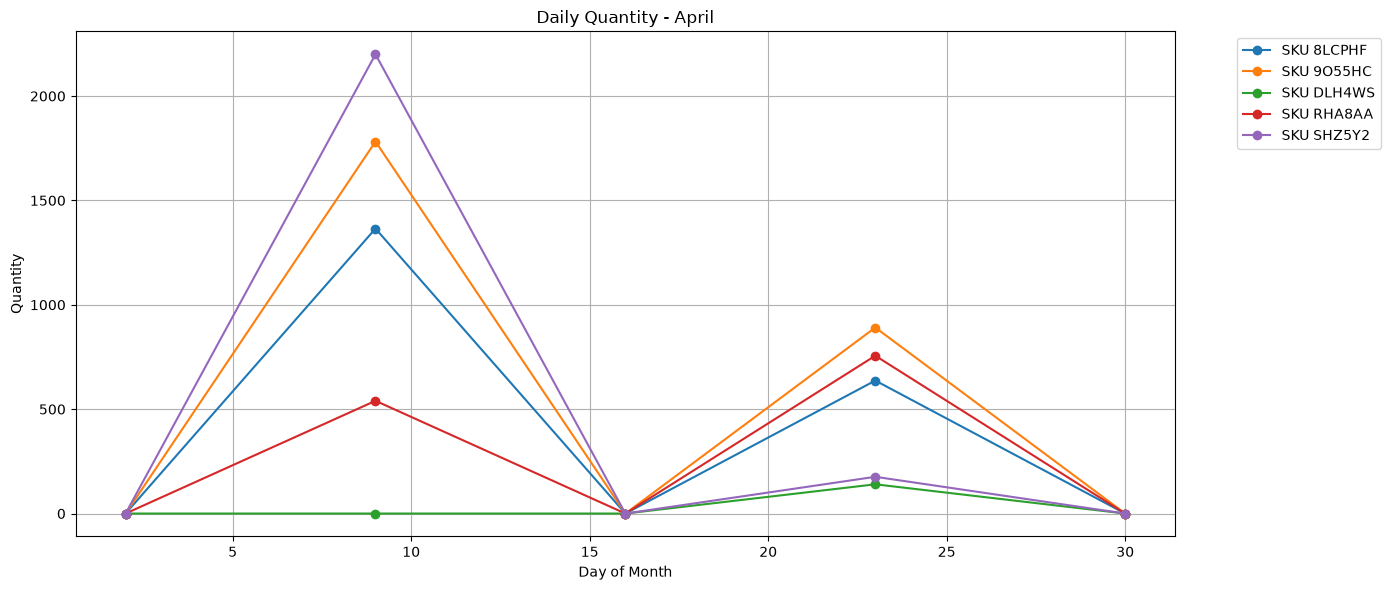

In [80]:
plot_daily_qty_for_month(
    data_forecast_template,
    month=4
)

In [81]:
data_forecast_template.to_csv('.././data/data_processed.csv', index=False)

3.5 Add day features for easier to EDA:

In [82]:
data_forecast['month'] = data_forecast['shipped_date'].dt.month
data_forecast['day'] = data_forecast['shipped_date'].dt.day
data_forecast['dayofweek'] = data_forecast['shipped_date'].dt.dayofweek
data_forecast['weekofyear'] = data_forecast['shipped_date'].dt.isocalendar().week

data_forecast['is_even_day'] = (data_forecast['day'] % 2 == 0).astype(int)
print(data_forecast.head())

  shipped_date     sku   qty   revenue      COGS  month  day  dayofweek  \
1   2021-01-01  0FKFLA   780  32028.36  13104.00      1    1          4   
4   2021-01-01  11HSH1   150   7137.90   6209.97      1    1          4   
5   2021-01-01  13KMDL   444  31048.92   8018.64      1    1          4   
6   2021-01-01  17KYMH   966  54144.30  25411.60      1    1          4   
9   2021-01-01  1JKADT  3038  46742.67  33627.72      1    1          4   

   weekofyear  is_even_day  
1          53            0  
4          53            0  
5          53            0  
6          53            0  
9          53            0  


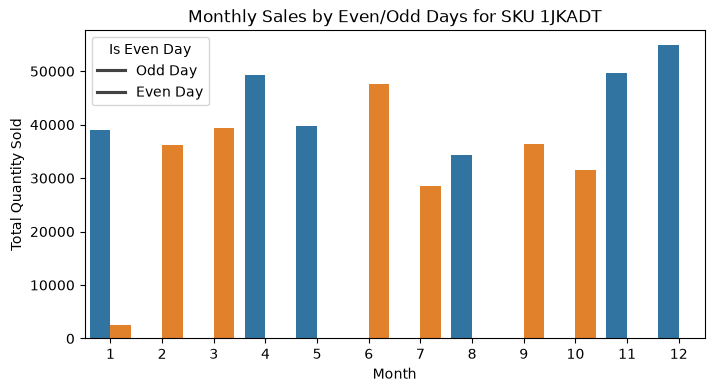

In [83]:
# data_forecast.loc[(data_forecast['sku']=='1JKADT')&(data_forecast['is_even_day']==1)&(data_forecast['qty']>0)]

data_plot = data_forecast[data_forecast['sku']=='1JKADT'].groupby(['month','is_even_day'])[['qty']].sum().reset_index()


plt.figure(figsize=(8, 4))
sns.barplot(data=data_plot, x='month', y='qty', hue='is_even_day')
plt.title('Monthly Sales by Even/Odd Days for SKU 1JKADT')
plt.xlabel('Month')
plt.ylabel('Total Quantity Sold')
plt.legend(title='Is Even Day', labels=['Odd Day', 'Even Day'])
plt.show()

In [84]:
holidays = [
    # New Year
    "2021-01-01",
    "2021-01-02",
    "2021-01-03",

    # Lunar New Year (Tet Holiday)
    "2021-02-10",
    "2021-02-11",
    "2021-02-12",
    "2021-02-13",
    "2021-02-14",
    "2021-02-15",
    "2021-02-16",

    # Hung Kings Commemoration Day
    "2021-04-21",

    # Reunification Day & International Workers' Day
    "2021-04-30",
    "2021-05-01",
    "2021-05-02",
    "2021-05-03",

    # National Day
    "2021-09-02",
    "2021-09-03",
    "2021-09-04",
    "2021-09-05",

    # Christmas (optional depending on business context)
    "2021-12-24",
    "2021-12-25",
]

holidays = pd.to_datetime(holidays)
data_forecast["is_holiday"] = data_forecast["shipped_date"].isin(holidays).astype(int)

data_forecast.head()

,shipped_date,sku,qty,revenue,COGS,month,day,dayofweek,weekofyear,is_even_day,is_holiday
1,2021-01-01,0FKFLA,780,32028.36,13104.00,1,1,4,53,0,1
4,2021-01-01,11HSH1,150,7137.90,6209.97,1,1,4,53,0,1
5,2021-01-01,13KMDL,444,31048.92,8018.64,1,1,4,53,0,1
6,2021-01-01,17KYMH,966,54144.30,25411.60,1,1,4,53,0,1
9,2021-01-01,1JKADT,3038,46742.67,33627.72,1,1,4,53,0,1


In [85]:
data_forecast.groupby('is_holiday').agg({'qty': 'sum', 'sku':'count', 'COGS':'sum'}).reset_index()

,is_holiday,qty,sku,COGS
0,0,10231556,19522,1.992970e+08
1,1,695712,1371,1.426308e+07


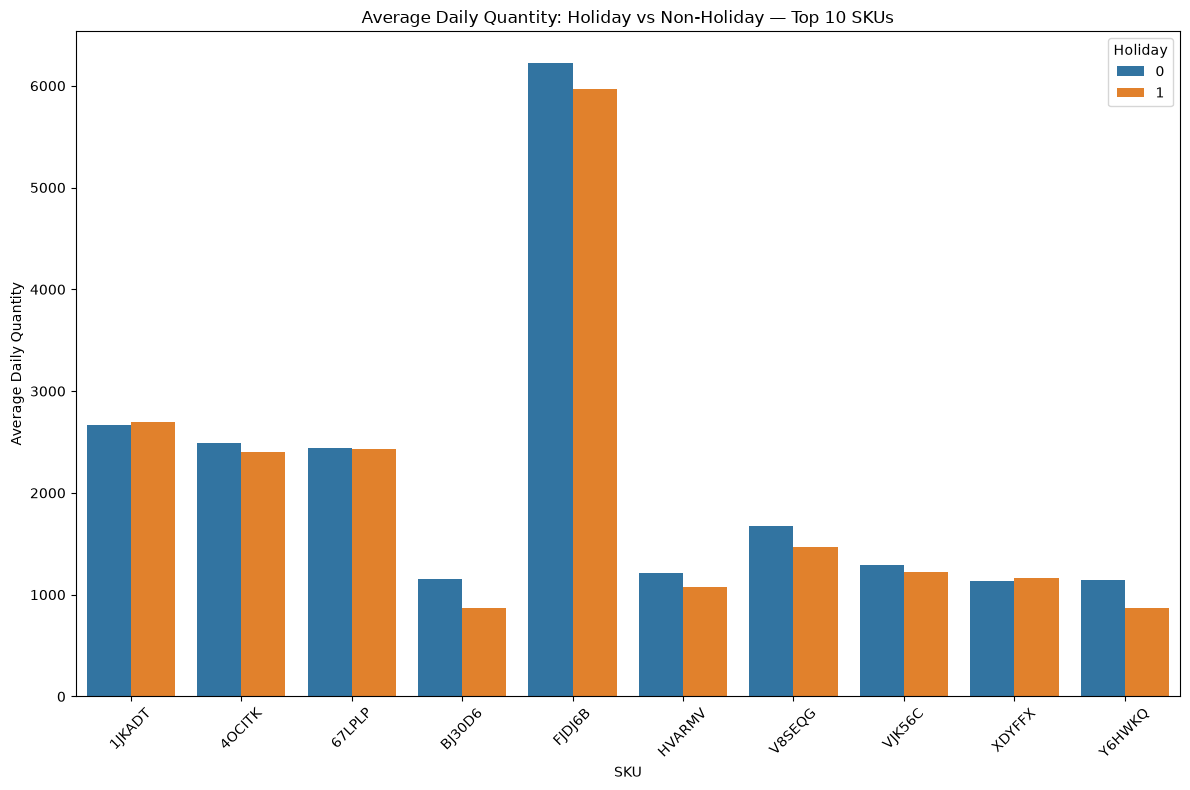

In [86]:
#lấy Top 10 SKU theo mean quantity:
top_10_skus = (
    data_forecast.groupby('sku')['qty']
    .sum()
    .nlargest(10)
    .index
)

data_plot = data_forecast[
    data_forecast['sku'].isin(top_10_skus)
].copy()

data_plot = (
    data_plot
    .groupby(['sku', 'is_holiday'])['qty']
    .mean()
    .reset_index()
)
#plt.figure(figsize=(12, 6))

plt.figure(figsize=(12, 8))

sns.barplot(
    data=data_plot,
    x='sku',
    y='qty',
    hue='is_holiday'
)

plt.title('Average Daily Quantity: Holiday vs Non-Holiday — Top 10 SKUs')
plt.xlabel('SKU')
plt.ylabel('Average Daily Quantity')
plt.legend(title='Holiday')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

* We need to understand the products in detail to identify potential factors that may affect sales, and then test these hypotheses with the data.

In [87]:
data_forecast["qty"].quantile([0.90, 0.95, 0.99, 0.995])

0.900    1188.00
0.950    1840.00
0.990    4121.28
0.995    6150.00
Name: qty, dtype: float64

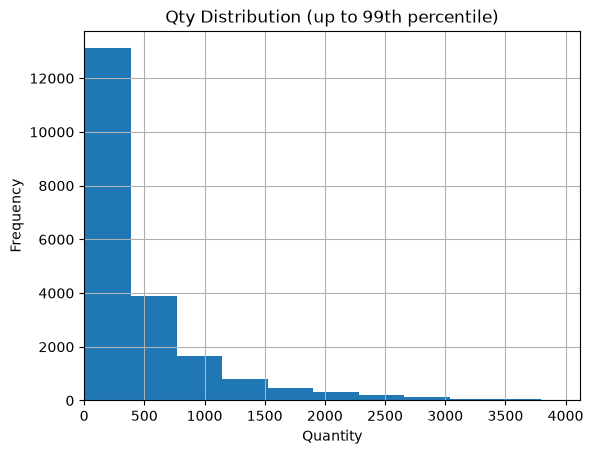

In [88]:
data_forecast["qty"].hist(bins=50)

plt.title("Qty Distribution (up to 99th percentile)")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.xlim(0, 4121.28)

plt.show()

3.5. Trend

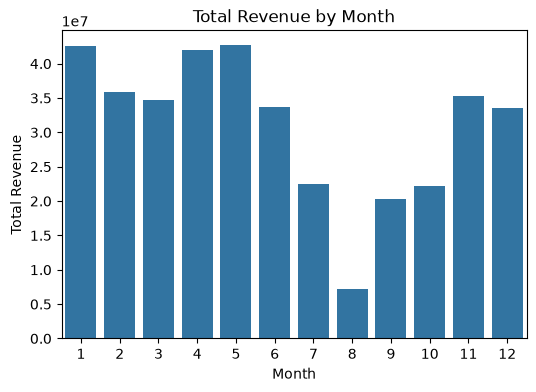

In [89]:
data_plot = data_forecast.groupby('month')['revenue'].sum().reset_index()
plt.figure(figsize=(6, 4))
sns.barplot(data=data_plot, x='month', y='revenue')
plt.title('Total Revenue by Month')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.show()

Some insights after EDA:
*
*

4. Handle Outlier

Before remove outliers: (48129, 7)


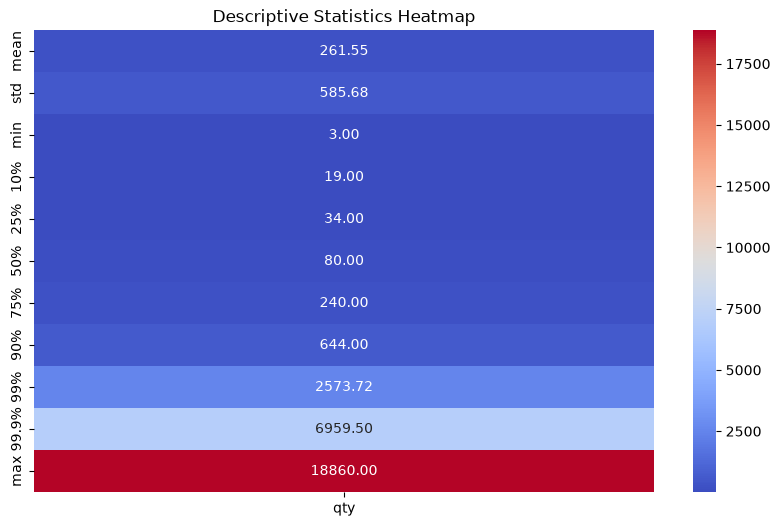

In [90]:
# Using heat map to visualize outliers
print("Before remove outliers:",data_filled.shape)
summary = (
    data_filled[["sku", "qty"]]
    .describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.99, 0.999])
    .iloc[1:]
)

plt.figure(figsize=(10, 6))
sns.heatmap(summary, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Descriptive Statistics Heatmap")
plt.show()

In [91]:
data_outliers_corrected = correct_outliers(data_filled, factor=3)

After remove outliers: (48129, 7)


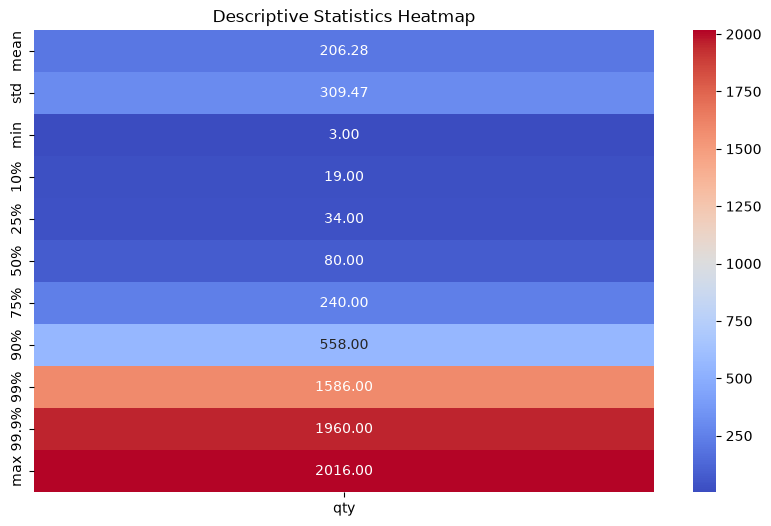

In [92]:
# Using heat map to visualize outliers
print("After remove outliers:",data_outliers_corrected.shape)
summary = (
    data_outliers_corrected[["sku", "qty"]]
    .describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.99, 0.999])
    .iloc[1:]
)

plt.figure(figsize=(10, 6))
sns.heatmap(summary, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Descriptive Statistics Heatmap")
plt.show()

In [93]:
print(data_processed.shape)
data_processed.head()

(48129, 7)


,shipped_date,sku,channel,qty,revenue,COGS,MOQ_orders
0,2021-01-01,089A0E,ADS,190,5027.40,2926.000000,56460
1,2021-01-01,089A0E,AWH,30,793.80,2328.115948,56460
2,2021-01-01,0FKFLA,AWH,780,32028.36,13104.000000,427545
3,2021-01-01,0G8Z4M,AWH,85,1307.81,595.000000,2516
4,2021-01-01,0NFJ14,FBM,38,2127.47,1723.250000,18734


In [94]:
#SKU nào đáng để forcast
sku_revenue = (
    data_processed
    .groupby('sku', as_index=False)['revenue']
    .sum()
    .sort_values('revenue', ascending=False)
)

sku_revenue['cumulative_revenue'] = sku_revenue['revenue'].cumsum()

total_revenue = sku_revenue['revenue'].sum()

sku_revenue['cumulative_pct'] = (
    sku_revenue['cumulative_revenue'] / total_revenue * 100
)

for target in [25, 50, 75, 90, 95, 99]:
    n_sku = (sku_revenue['cumulative_pct'] < target).sum() + 1
    print(f"{target}% doanh thu → {n_sku} SKU")



25% doanh thu → 7 SKU
50% doanh thu → 32 SKU
75% doanh thu → 85 SKU
90% doanh thu → 160 SKU
95% doanh thu → 214 SKU
99% doanh thu → 339 SKU


--> forcast cho 214 sku tạo ra 90% doanh thu, các sku còn lại sẽ để tồn kho như năm cũ

In [95]:
print(sku_revenue["sku"].head(10))

278    FJDJ6B
580    VJK56C
121    67LPLP
126    6HSD4J
153    7XL27C
96     4OCITK
398    LHR5LZ
22     1JKADT
329    HK1R6J
635    Y6HWKQ
Name: sku, dtype: str


In [96]:
#chỉ lấy dòng có sku nằm trong top 214 sku theo doanh thu
top_214_skus = sku_revenue.head(214)['sku']
data_processed = data_processed[
    data_processed['sku'].isin(top_214_skus)
].copy()

In [97]:
print(data_processed.shape)

(36023, 7)


In [98]:
selling_days = (
    data_processed[data_processed['qty'] > 0]
    .groupby('sku')['shipped_date']
    .nunique()
    .reset_index(name='selling_days')
    .sort_values('selling_days', ascending=False)
)
bins = [0,10,50,120,185]
labels = ['0-10 days', '11-50 days', '51-120 days','>120 days']

selling_days['group'] = pd.cut(
    selling_days['selling_days'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

selling_days['group'].value_counts().sort_index()

group
0-10 days        0
11-50 days       6
51-120 days     47
>120 days      161
Name: count, dtype: int64

In [99]:
# Tổng demand theo ngày
data_processed['shipped_date'] = pd.to_datetime(data_processed['shipped_date'])

data_processed = (
    data_processed
    .groupby('shipped_date', as_index=False)
    .agg({
        'qty': 'sum',
        'revenue': 'sum',
        'COGS': 'sum'
    })
)

data_processed = data_processed.sort_values('shipped_date').reset_index(drop=True)

In [100]:
data_processed.head()

,shipped_date,qty,revenue,COGS
0,2021-01-01,85476,3651511.93,2.067670e+06
1,2021-01-03,66886,2790740.37,1.430128e+06
2,2021-01-05,51863,2361814.66,1.168319e+06
3,2021-01-07,17678,735174.21,3.847410e+05
4,2021-01-09,70352,2951706.19,1.510104e+06


In [101]:
sku_list = ['67LPLP', '6HSD4J', '7XL27C', '4OCITK', 'LHR5LZ', '1JKADT', 'HK1R6J', 'Y6HWKQ']

plot_data = data_processed[
    data_processed['sku'].isin(sku_list)
].copy()

plt.figure(figsize=(14, 6))

for sku in sku_list:
    sku_data = plot_data[plot_data['sku'] == sku].sort_values('week')

    plt.plot(
        sku_data['week'],
        sku_data['qty'],
        label=sku
    )

plt.xlabel('Week')
plt.ylabel('Quantity')
plt.title('Weekly Quantity by SKU')
plt.legend()
plt.tight_layout()
plt.show()

KeyError: 'sku'

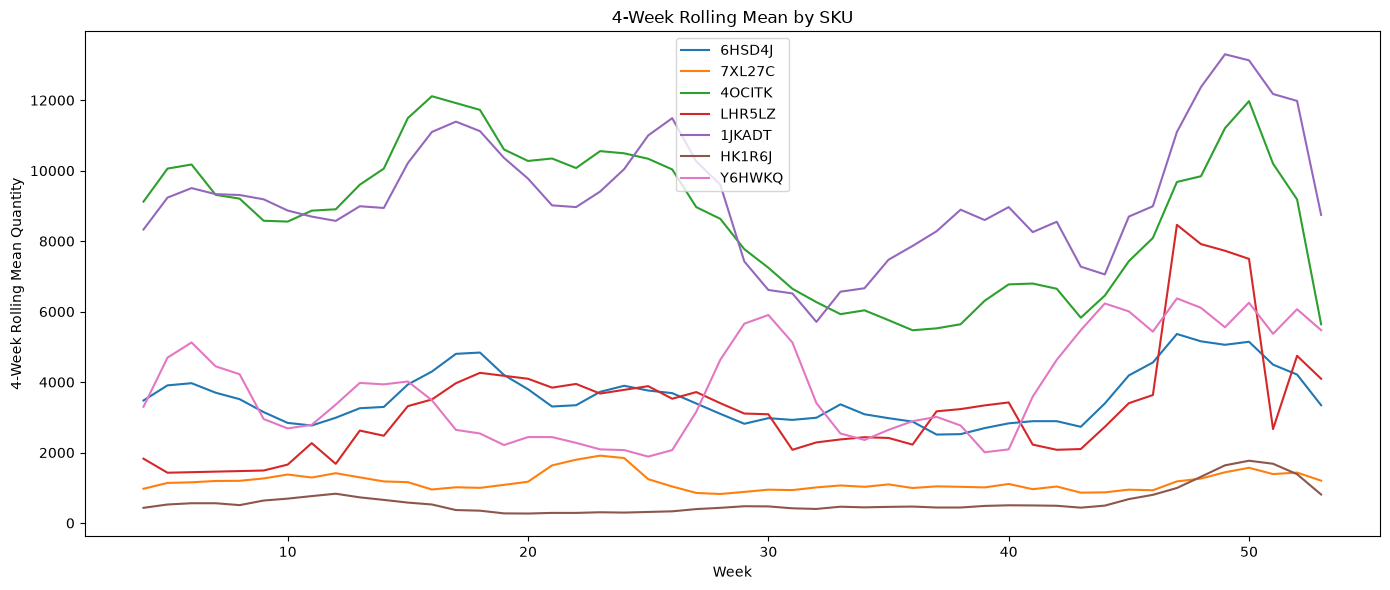

In [ ]:
sku_list = [ '6HSD4J', '7XL27C', '4OCITK', 'LHR5LZ', '1JKADT', 'HK1R6J', 'Y6HWKQ']

plot_data = data_processed[data_processed['sku'].isin(sku_list)].copy()

# Rolling mean 4 tuần liên tiếp
plot_data['rolling_mean_4'] = (
    plot_data
    .sort_values(['sku', 'week'])
    .groupby('sku')['qty']
    .transform(lambda x: x.rolling(4).mean())
)

plt.figure(figsize=(14, 6))

for sku in sku_list:
    sku_data = plot_data[plot_data['sku'] == sku].sort_values('week')
    plt.plot(
        sku_data['week'],
        sku_data['rolling_mean_4'],
        label=sku
    )

plt.xlabel('Week')
plt.ylabel('4-Week Rolling Mean Quantity')
plt.title('4-Week Rolling Mean by SKU')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
data_processed[['deviation', 'next_deviation']].corr()

,deviation,next_deviation
deviation,1.000000,-0.132243
next_deviation,-0.132243,1.000000


In [ ]:
data_processed.to_csv('.././data/data_processed.csv', index=False)